<a href="https://colab.research.google.com/github/nkocjan/computational-intelligence-methods/blob/dev/lab01/lab01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Sprawozdanie lab 01**
******

In [1]:
# Dodanie potrzebnych importów
from sklearn.linear_model import Perceptron
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
from sklearn.utils._testing import ignore_warnings
from sklearn.exceptions import ConvergenceWarning

**Zadanie 1**

Generacja danych o rozkładzie normalnym

Pierwsze ćwiczenie polegało na wygenerowaniu po 100 punktów z dwóch klas danych. Pierwsza klasa miała średnią [0,1] i wariancję równą 1,
natomiast druga klasa była uśredniona w punkcie [1,1], również z wariancją 1. Następnie dane te
zostały podzielone na zestawy treningowe, a perceptron był trenowany kolejno na 5, 10, 20 i 100
punktach.


In [ ]:
K1 = np.random.normal([0,-1], 1, [100,2])
K2 = np.random.normal([1,1], 1, [100,2])

X = np.vstack((K1, K2))
y = np.hstack((np.zeros(100), np.ones(100)))

train_sizes = [5, 10, 20, 100]

results = []

Przygotowano pętlę, gdzie dla każdego *train_sizes* wyznaczono zbiory:
*   X_train - zbiór uczący
*   X_test - zbiór testujący
*   y_train - wyniki zbiór uczący
*   y_test - wyniki zbiór testujący

Następnie przygotowano *Perceptron* oraz wykonano na nim nauczanie. W celu prezentacji i analizy wyników dla każdego rozmiaru zbioru uczącego wskazano i opisano:
*   score dla train - jak dobrze model się nauczył
*   n_iter_ - liczba iteracji do konwergencji
*   accuracy_score - dokładność klasyfikacji, stosunek poprawnych predykcji do błędnych



Zbiór uczący: 5 próbek
Liczba faktycznych epok: 7
Trafność (accuracy) na zbiorze treningowym: 1.00
Trafność (accuracy) na zbiorze testowym: 0.77



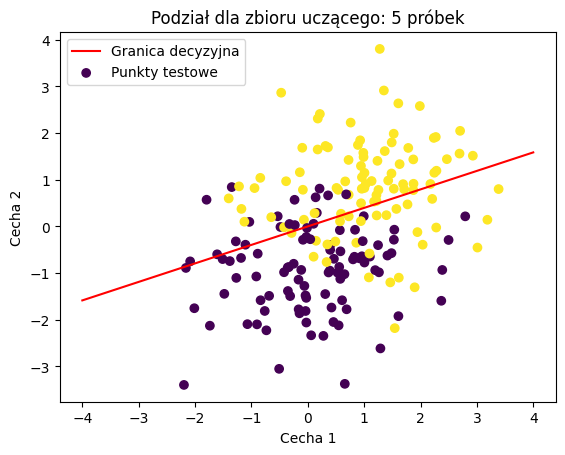





Zbiór uczący: 10 próbek
Liczba faktycznych epok: 7
Trafność (accuracy) na zbiorze treningowym: 1.00
Trafność (accuracy) na zbiorze testowym: 0.83



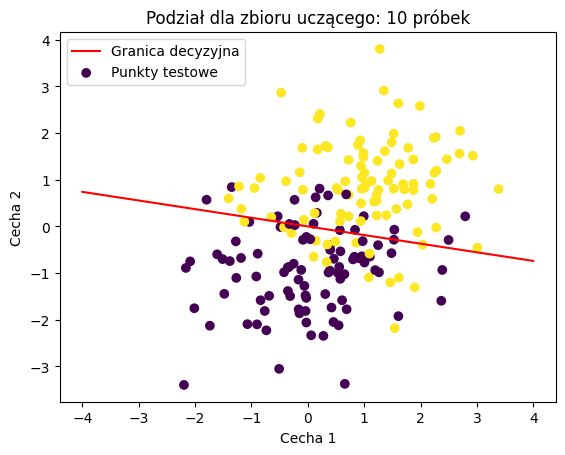





Zbiór uczący: 20 próbek
Liczba faktycznych epok: 13
Trafność (accuracy) na zbiorze treningowym: 0.70
Trafność (accuracy) na zbiorze testowym: 0.82



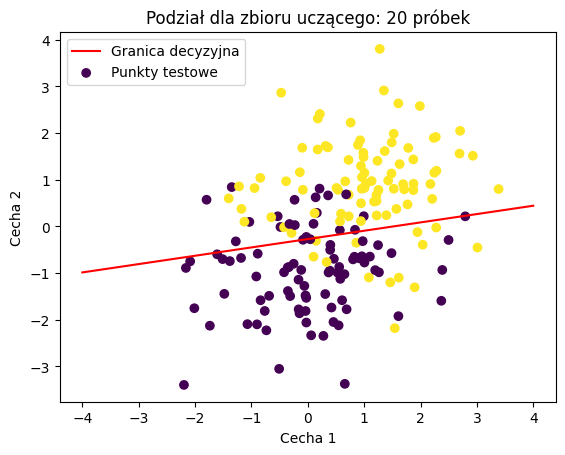





Zbiór uczący: 100 próbek
Liczba faktycznych epok: 11
Trafność (accuracy) na zbiorze treningowym: 0.82
Trafność (accuracy) na zbiorze testowym: 0.85



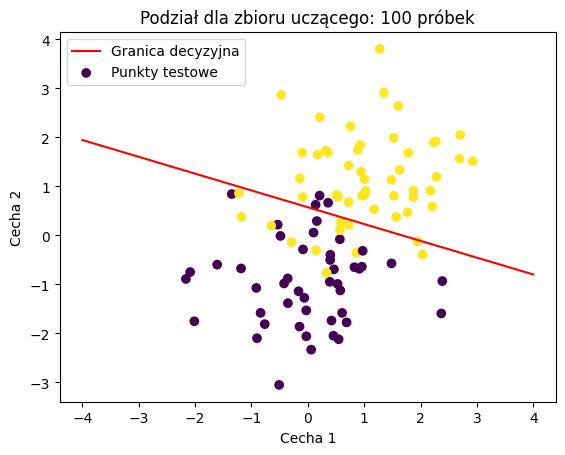

In [ ]:
for i, train_size in enumerate(train_sizes):
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=0)

    perceptron = Perceptron(tol=1e-3, max_iter=500)
    perceptron.fit(X_train, y_train)

    print(f"Zbiór uczący: {train_size} próbek")
    print(f"Liczba faktycznych epok: {perceptron.n_iter_}")

    train_score = perceptron.score(X_train, y_train)
    print(f"Trafność (accuracy) na zbiorze treningowym: {train_score:.2f}")

    test_score = perceptron.score(X_test, y_test)
    print(f"Trafność (accuracy) na zbiorze testowym: {test_score:.2f}\n")

    x1 = np.linspace(-4,4,100)
    x2 = -(1./perceptron.coef_[0][1])*(perceptron.coef_[0][0]*x1+perceptron.intercept_[0])
    plt.plot(x1, x2, '-r', label="Granica decyzyjna")
    plt.scatter(np.array(X_test)[:,0], np.array(X_test)[:,1], c=y_test, label="Punkty testowe")
    plt.legend()
    plt.title(f"Podział dla zbioru uczącego: {train_size} próbek")
    plt.xlabel("Cecha 1")
    plt.ylabel("Cecha 2")
    plt.show()

    print("\n\n\n")

**Wnioski zadanie 1**

Z wyników, możemy zauważyć że wraz z wzrostem liczebności zbioru uczącego, poprawiała się trafność dla zbioru testowego, natomiast malała dla trenującego. Przyczyna takiego zachowania jest dość prosta, dla 5 próbek w zbiorze uczącym, program bardzo łatwo rozpozna co się dzieję i trafność osiągnie nawet 1.0, podobnie jak dla 10. Natomiast ucząc model na 5 próbkach, może mieć problem z rozpoznaniem elementów dla zbioru testowego o liczebności 195. Stąd wynikają te zależności.

Analiza uwzględniła również liczbę faktycznych epok dla zbioru treningowego. Zauważamy że dla małego zbioru treningowego, liczba epok jest niska, oraz rośnie wraz z wzrostem liczebności danych treningowych, co też wydaje się logiczne i mało zaskakujące.

Dla każdego testu zostały również wygenerowane oraz opisane wykresy, w jaki sposób Perceptron oddzielał klasy dla każdego przypadku.

**Zadanie 2**

Klasyfikacja czystości benzyny

In [ ]:
data = pd.read_csv('./fuel.txt', delimiter=",")

Wykorzystanko plik fuel.txt, który zawierał trzy kolumny z właściwościami benzyny, oraz jedną kolumnę kolumnę z klasyfikacją jej jakości oznaczoną jako A lub B.

Dane dla kolumn *c_1*, *c_2*, *c_3*, mają bardzo różną skalę, dlatego wymagane jest znormalizowanie ich. Wybrano metodę MinMaxScaler z biblioteki sklearn, oraz znormalizowano dane do zakresu od 0 do 100

In [ ]:
features = ['c_1', 'c_2', 'c_3']
scaler = MinMaxScaler(feature_range=(0, 100))
data[features] = scaler.fit_transform(data[features])

Model jakim jest perceptron, wymaga podania mu wartości numerycznych, dlatego klasa czystości ***A*** została oznaczona jako 0, a ***B*** jako 1.

Następnie rozdzielono dane na zbiór X oraz y. W tym wpadku przyjęto zbiór treningowy jako 100%, stąd to proste oznaczenie.

In [ ]:
data['purity_class'] = np.where(data['purity_class'] == 'B', 1, 0).astype(int)
X = data.iloc[:,:-1].values
y = data.iloc[:, -1].values

Zgodnie z poleceniem, sieć została przetrenowana pięciokrotnie, ograniczono perceptron do 100 iteracji. W celu analizy, dla każdej iteracji sprawdzono liczbę epok potrzebną do konwergencji, oraz trafność.

Wygenerowano również wykresy dla każdej iteracji, aby zwizualizować w jaki sposób perceptron dzieli paliwo na kategorię A oraz B.

W celu wprowadzenia pewnej randomizacji podczas analizy dla kolejnych iteracji, do metody Perceptron dodano argument random_state=i, dzięki czemu wartość losowa będzie inna dla każdej iteracji. W innym wypadku, wszystkie 5 wyników byłoby takie same.




Iteracja 1
Liczba epok do konwergencji: 8
Trafność na zbiorze: 0.90



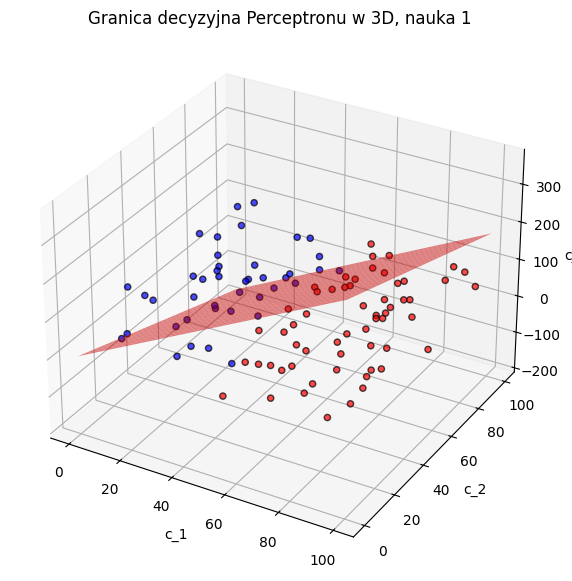




Iteracja 2
Liczba epok do konwergencji: 15
Trafność na zbiorze: 0.89



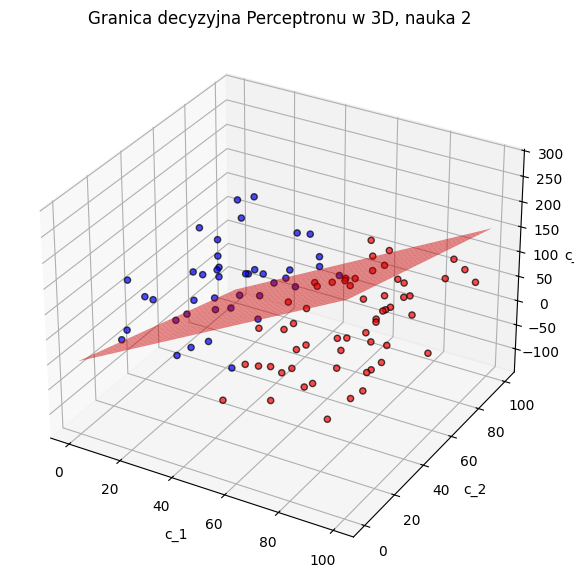




Iteracja 3
Liczba epok do konwergencji: 13
Trafność na zbiorze: 0.74



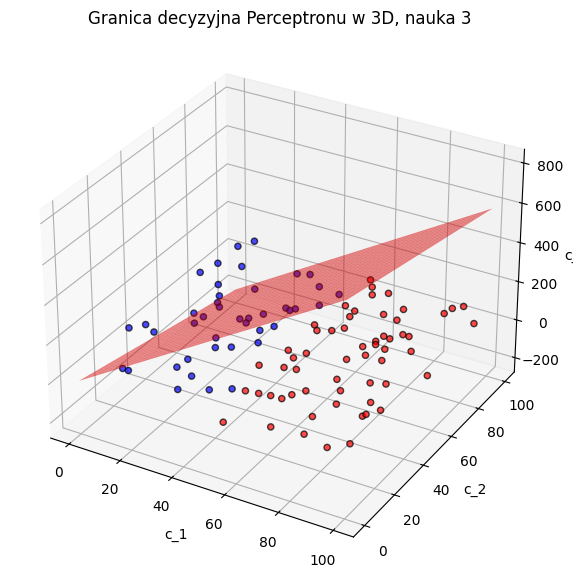




Iteracja 4
Liczba epok do konwergencji: 7
Trafność na zbiorze: 0.86



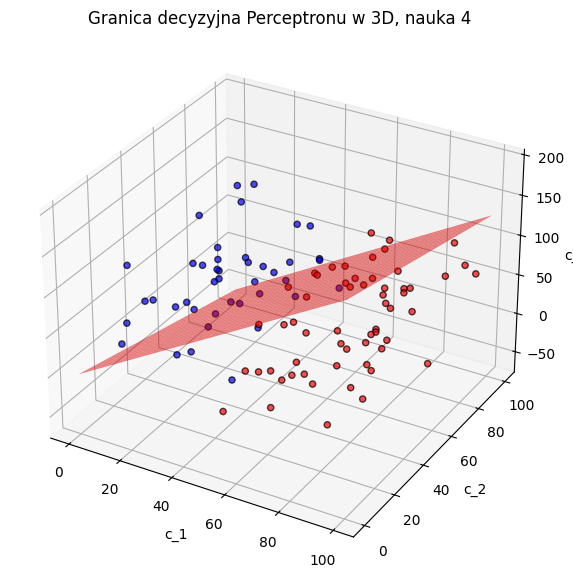




Iteracja 5
Liczba epok do konwergencji: 7
Trafność na zbiorze: 0.81



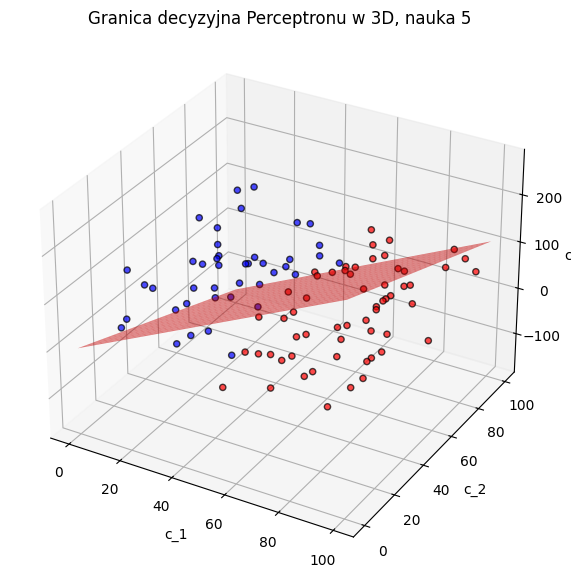

In [ ]:
for i in range(5):
  perceptron = Perceptron(tol=1e-3, max_iter=100, random_state=i)
  perceptron.fit(X, y)
  w = perceptron.coef_[0]
  b = perceptron.intercept_[0]
  train_score = perceptron.score(X, y)

  print(f"\n\n\nIteracja {i+1}")
  print(f"Liczba epok do konwergencji: {perceptron.n_iter_}")
  print(f"Trafność na zbiorze: {train_score:.2f}\n")

  x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 30)
  x2_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 30)
  x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

  x3_grid = -(w[0] / w[2]) * x1_grid - (w[1] / w[2]) * x2_grid - (b / w[2])

  fig = plt.figure(figsize=(10, 7))
  ax = fig.add_subplot(111, projection='3d')

  ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='bwr', alpha=0.7, edgecolors='k')
  ax.plot_surface(x1_grid, x2_grid, x3_grid, color='red', alpha=0.5)

  ax.set_xlabel("c_1")
  ax.set_ylabel("c_2")
  ax.set_zlabel("c_3")
  ax.set_title("Granica decyzyjna Perceptronu w 3D, nauka " + (i + 1).__str__())

  plt.show()



Analizując rezultaty można zauważyć, że wyniki trafności wachają się między 0.74 a 0.90, co wskazuje na niestabilność modelu. Może to być spowodowane danymi, które nie są idealnie liniowo separowalne, bądź niepoprawnie dobraną metodą normalizacji danych do zakresu 0 - 100. Mimo to średnia trafność jest wysoka co wskazuje że model dobrze klasyfikuje kategorię paliwa, lecz nie jest idealny.

Liczba epok wymaganych do nauczenia modelu również się różniła, co może wskazywać, że jakość modelu zależy od losowego początkowego ustawienia wag

**Zadanie 3**

Wykorzystany zostanie zbiór danych Iris, zawiera on próbki, gdzie na podstawie 4 danych wejściowych, zostanie określone, jaki to gatunek ( Virginica, Versicolor, Setosa ). Badanie przeprowadzono dla 200 prób, każda próba losowo dzieli dane wejściowe na treningowe i testowe w proporcjach 80 / 20.

W celu analizy, wybrano 3 macierze pomyłek, dla każdej obliczono trafność wyników, jako stosunek sumy danych z diagonali, do wszystkich orób. Obliczono również średnią dokładność dla 200 prób, oraz odchylenie standardowe.

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

attempts = 200

accuracies = []
confusion_matrices = []

for i in range(attempts):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

  perceptron = Perceptron(tol=1e-3, max_iter=50, random_state=42)
  perceptron.fit(X_train, y_train)
  y_pred = perceptron.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)
  accuracies.append(accuracy)

  cm = confusion_matrix(y_test, y_pred)
  confusion_matrices.append(cm)

print("Przykładowe macierze: ")
print(confusion_matrices[0])
print(f"Dokładność macierzy liczona z funkcji accuracy_score:  {accuracies[0]:.2f}")
print(f"Dokładność macierzy liczona na podstawie diagonali:  {np.trace(confusion_matrices[0]) / np.sum(confusion_matrices[0]):.2f}")
print(confusion_matrices[1])
print(f"Dokładność macierzy liczona z funkcji accuracy_score:  {accuracies[1]:.2f}")
print(f"Dokładność macierzy liczona na podstawie diagonali:  {np.trace(confusion_matrices[100]) / np.sum(confusion_matrices[100]):.2f}")
print(confusion_matrices[2])
print(f"Dokładność macierzy liczona z funkcji accuracy_score:  {accuracies[2]:.2f}")
print(f"Dokładność macierzy liczona na podstawie diagonali:  {np.trace(confusion_matrices[199]) / np.sum(confusion_matrices[199]):.2f}")

print(f"\nŚrednia dokładność dla {attempts} prób: {np.mean(accuracies):.2f}")
print(f"Odchylenie standardowe dokładności dla {attempts} prób: {np.std(accuracies):.2f}")


Przykładowe macierze: 
[[11  0  0]
 [ 1  4  6]
 [ 0  0  8]]
Dokładność macierzy liczona z funkcji accuracy_score:  0.77
Dokładność macierzy liczona na podstawie diagonali:  0.77
[[11  0  0]
 [ 0  9  2]
 [ 0  0  8]]
Dokładność macierzy liczona z funkcji accuracy_score:  0.93
Dokładność macierzy liczona na podstawie diagonali:  0.80
[[ 9  0  0]
 [ 0  1 10]
 [ 0  0 10]]
Dokładność macierzy liczona z funkcji accuracy_score:  0.67
Dokładność macierzy liczona na podstawie diagonali:  0.63

Średnia dokładność dla 200 prób: 0.72
Odchylenie standardowe dokładności dla 200 prób: 0.17


Średnia dokładność dla 200 prób wyniosła 0.72, a odchylenie standardowe 0.17. Wskazuje to na problemy perceptronu z klasyfikacją irisów w wielu przypadkach, oraz na małą stabilność.

Analizując macierze błędów, możemy zauważyć, że w trzeciej, wiersz dla klasy 2 zawiera zaledwie 1 poprawnie odczytany iris.

Jest to najprawdopodobniej spowodowanie tym, że dane nie są liniowo separowalne, a perceptron jest modelem liniowym, więc nie jest w stanie ich oddzielić.


**Zadanie 4**

Przeanalizowano sytuację, co się stanie gdy perceptron będzie uczony na różnych proporcjach danych uczących do testowych. Dla zachowania losowości perceptronu ustawiono random_state na 2.

Badanie zostało przeprowadzone na trzech rozmiarach zbioru uczącego, tj. 50%, 70%, 90%. Można się spodziewać, że wraz z wzrostem rozmiaru zbioru uczącego, wzrośnie również dokładność, a macierz pomyłek będzie wskazywała poprawniejsze wartości.

In [ ]:
X = iris.data
y = iris.target

test_sizes = [0.5, 0.3, 0.1]

for test_size_iter in test_sizes:
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_iter)

  perceptron = Perceptron(tol=1e-3, max_iter=50, random_state=2)
  perceptron.fit(X_train, y_train)
  y_pred = perceptron.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)
  cm = confusion_matrix(y_test, y_pred)

  print(f"Rozmiar zestawu testowego: {test_size_iter}")
  print(f"Dokładność na podstawie score:  {perceptron.score(X_test, y_test):.2f}")
  print(f"Dokładność macierzy: {accuracy:.2f}")
  print("Macierz pomyłek:")
  print(cm)
  print("\n")

Rozmiar zestawu testowego: 0.5
Dokładność na podstawie score:  0.51
Dokładność macierzy: 0.51
Macierz pomyłek:
[[ 7 18  0]
 [ 0 29  0]
 [ 0 19  2]]


Rozmiar zestawu testowego: 0.3
Dokładność na podstawie score:  0.98
Dokładność macierzy: 0.98
Macierz pomyłek:
[[15  0  0]
 [ 0 13  0]
 [ 0  1 16]]


Rozmiar zestawu testowego: 0.1
Dokładność na podstawie score:  0.93
Dokładność macierzy: 0.93
Macierz pomyłek:
[[9 0 0]
 [1 1 0]
 [0 0 4]]




Dokładność wyników na podstawie metody określającej czy uczenie było udane klasyfikuje się jako 0.51, 0.98, 0.93. Zakładano że wraz z wzrostem zbioru uczącego, wynik bęzie wzrastał, natomiast zauważono, że pomiędzy zbiorem uczącym 70% a 90% nastąpił spadek o 0.05. Przyczyną jest najprawdopodobniej użycie perceptronu do danych, które nie do końca są separowalne liniowo.

Zauważamy, że dla 50% zestawu uczącego dokładność to zaledwie 0.51. Największe problemy wystąpiły przy rozpoznaniu gatunku pierwszego (18 pomyłek) oraz trzeciego (19 pomyłek). Można łatwo wysnuć wnioski, że 50%-owy zbiór uczący to jednak zbiór zbyt mały, aby dobrze nauczyć perceptron

**Zadanie 5**

Badanie irysów na podstawie epok.
Założono podział danych uczących do testujących, taki jak dla zadania 3, tj. 80% / 20%.

Zbadano rezulaty dla ilości epok: 1, 2, 5, 10, 20, 50, 100, 200, 500

W tym przypadku przeprowadzono standaryzację danych z użyciem metody StandardScaler(), ponieważ badając liczbę epok, zależy nam, aby perceptron nie wprowadzał kolejnych iteracji po to, aby nadać wagi dla nierównej skali, lecz skupił się na nauce. W zadaniu 3 i 4 było to pomijalne.

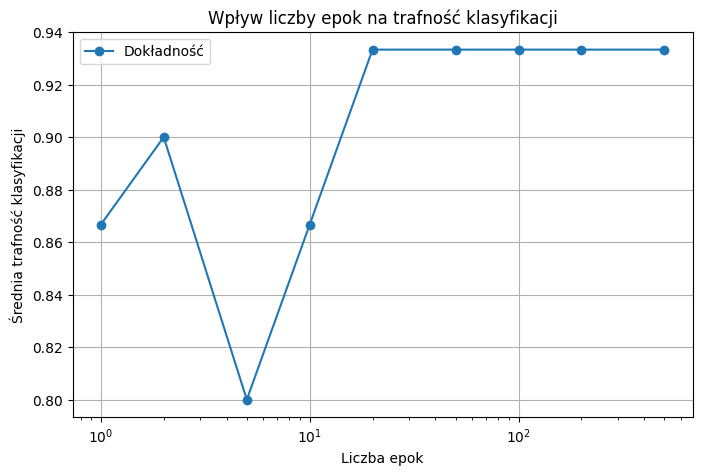

Żądane epoki: 1, Faktyczne epoki: 1, Dokładność: 0.87
Żądane epoki: 2, Faktyczne epoki: 2, Dokładność: 0.90
Żądane epoki: 5, Faktyczne epoki: 5, Dokładność: 0.80
Żądane epoki: 10, Faktyczne epoki: 10, Dokładność: 0.87
Żądane epoki: 20, Faktyczne epoki: 15, Dokładność: 0.93
Żądane epoki: 50, Faktyczne epoki: 15, Dokładność: 0.93
Żądane epoki: 100, Faktyczne epoki: 15, Dokładność: 0.93
Żądane epoki: 200, Faktyczne epoki: 15, Dokładność: 0.93
Żądane epoki: 500, Faktyczne epoki: 15, Dokładność: 0.93


In [ ]:
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

epochs = [1, 2, 5, 10, 20, 50, 100, 200, 500]
accuracies = []
actual_epochs = []

for epoch in epochs:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConvergenceWarning)

        perceptron = Perceptron(max_iter=epoch, tol=1e-10, early_stopping=False)
        perceptron.fit(X_train, y_train)

    y_pred = perceptron.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    actual_epochs.append(perceptron.n_iter_)

plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracies, marker='o', linestyle='-', label="Dokładność")
plt.xlabel("Liczba epok")
plt.ylabel("Średnia trafność klasyfikacji")
plt.xscale("log")
plt.title("Wpływ liczby epok na trafność klasyfikacji")
plt.legend()
plt.grid(True)
plt.show()

results_df = pd.DataFrame({"Żądane epoki": epochs, "Faktyczne epoki": actual_epochs, "Dokładność": accuracies})

for epoch, actual, acc in zip(epochs, actual_epochs, accuracies):
    print(f"Żądane epoki: {epoch}, Faktyczne epoki: {actual}, Dokładność: {acc:.2f}")



Analizując wyniki, zauważono, że trafność rośnie w pierwszych epokach, z sporym spadkiem ( 0.9 -> 0.8 ) pomiędzy ilością epok 2 oraz 5. Wynika to z tego, że jest to zbyt mała ilość epok, aby perceptron mógł dobrać odpowiednie wagi, dlatego wyniki, mogą być lekko "losowe", lecz od liczby epok 20, stabilizują się. Zauważamy, że faktyczna liczba epok stabilizuje się na ilośći 15, co oznacza, że badanie dla epok >= 20, nie da nam poprawniejszej dokładności.